In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Duplicate Question.csv')
print(df.shape)
df.sample(5)

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
214956,214956,320693,320694,What are some alternative solutions to unemplo...,List some of the key events that contributed t...,0
346851,346851,334101,475239,What is the difference between application pro...,What is the difference in learning programming...,0
837,837,1669,1670,How can I wake up early in the morning?,How can I get up early in the morning?,1
326747,326747,453108,453109,Is it a good idea forcing Redis cache on my ne...,The E-commerce business is booming in India. H...,0
158144,158144,120561,169835,How can I become a race car or F1 driver?,How do I become an F1 driver when you have lim...,1


In [3]:
df = df.sample(30000,random_state=2)
print(df.shape)
df.sample(5)

(30000, 6)


,id,qid1,qid2,question1,question2,is_duplicate
157936,157936,246823,120568,Why does everyone hate Wesley Crusher?,What should I do if I feel like everyone hates...,0
321760,321760,136803,447492,How much time would resetting Windows 10 norma...,What will happen after resetting Windows 10?,0
66695,66695,115560,115561,What are some of the good small prayers in Islam?,What are the similarities and differences betw...,0
294016,294016,78754,415835,Why did my friend leave me?,What will I do if all my friends leave me?,0
10495,10495,20324,20325,What do Visually impaired people imagine when ...,What do blind people think about when they mas...,1


In [4]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

Number of duplicate and non-duplicate questions is_duplicate
0    19013
1    10987
Name: count, dtype: int64
Distributions of Questions is_duplicate
0    63.376667
1    36.623333
Name: count, dtype: float64
Axes(0.125,0.11;0.775x0.77)


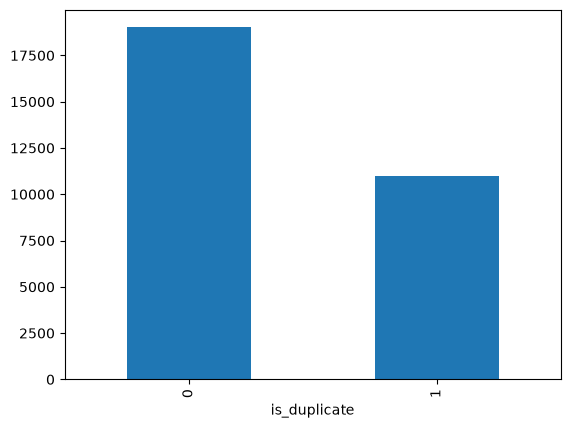

In [6]:
# Distribution of duplicate and non-duplicate questions 
print('Number of duplicate and non-duplicate questions', df['is_duplicate'].value_counts())
print('Distributions of Questions',(df['is_duplicate'].value_counts() / df['is_duplicate'].count()) * 100)
print(df['is_duplicate'].value_counts().plot(kind='bar'))

In [7]:
# Repeated questions 
qid = pd.Series(df['qid1'].to_list() + df['qid2'].to_list())
print("number of unique questions --> ",np.unique(qid).shape[0])

x = qid.value_counts()>1 
print('Repeated questions --> ', x[x].shape[0])

number of unique questions -->  55299
Repeated questions -->  3480


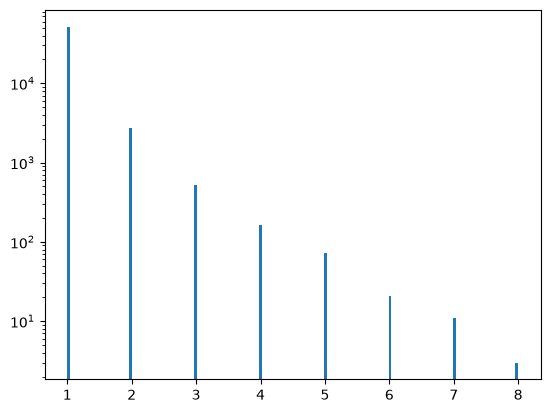

In [8]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')

# Feature Engineering

In [9]:
# q1 len 
df['q1_len'] = df['question1'].str.len()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35


In [10]:
# q2 len 
df['q2_len'] = df['question2'].str.len()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [11]:
#  q1 words 
df['q1_words'] = df['question1'].str.split().str.len()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5


In [12]:
# q2 words 
df['q2_words'] = df['question2'].str.split().str.len()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [13]:
def common_words(row): 
    w1 =set(map(lambda word:word.lower().strip(), row['question1'].split(' ')))
    w2 = set(map(lambda word:word.lower().strip(),row['question2'].split(' ')))
    return len(w1 & w2)

In [14]:
df['common_wrods'] = df.apply(common_words,axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [15]:
def total_words(row): 
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split()))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split()))
    return (len(w1) + len(w2))

In [16]:
df['total_words'] = df.apply(total_words,axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods,total_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [17]:
df['words_share']  = np.round(df['common_wrods']/df['total_words'],2)
df.head()  

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods,total_words,words_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


minimum characters 2
maximum characters 391
average num of characters 59


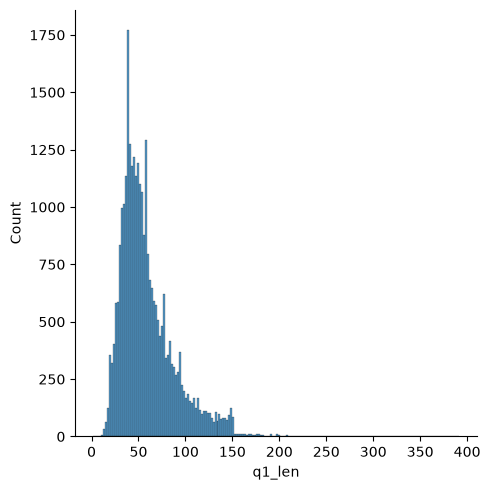

In [18]:
# Analysis of features
sns.displot(df['q1_len'])
print('minimum characters',df['q1_len'].min())
print('maximum characters',df['q1_len'].max())
print('average num of characters',int(df['q1_len'].mean()))

minimum characters 6
maximum characters 1151
average num of characters 60


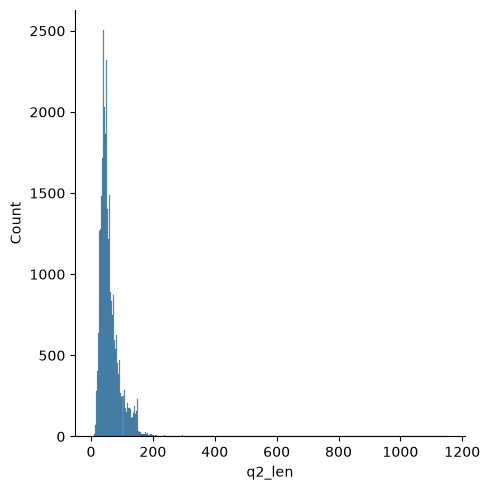

In [19]:
sns.displot(df['q2_len'])
print('minimum characters',df['q2_len'].min())
print('maximum characters',df['q2_len'].max())
print('average num of characters',int(df['q2_len'].mean()))

minimum words 1
maximum words 72
average num of words 10


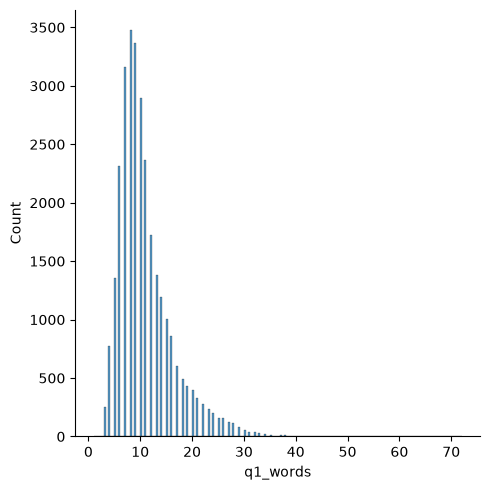

In [20]:
sns.displot(df['q1_words'])
print('minimum words',df['q1_words'].min())
print('maximum words',df['q1_words'].max())
print('average num of words',int(df['q1_words'].mean()))

minimum words 1
maximum words 237
average num of words 11


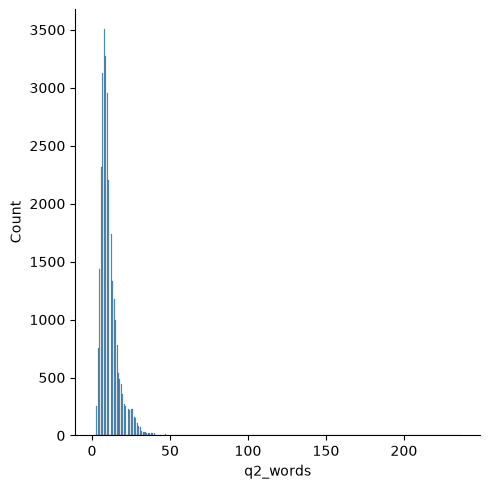

In [21]:
sns.displot(df['q2_words'])
print('minimum words',df['q2_words'].min())
print('maximum words',df['q2_words'].max())
print('average num of words',int(df['q2_words'].mean()))

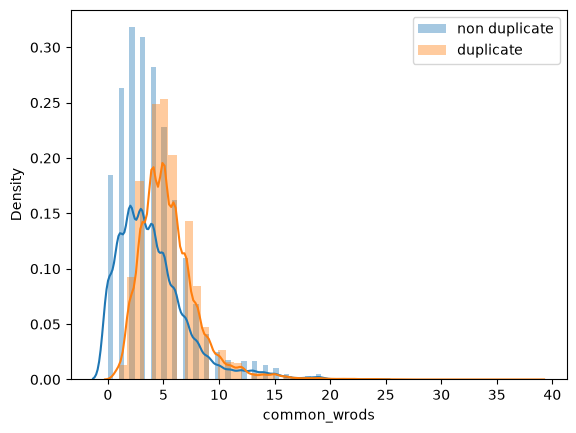

In [22]:
# common words
sns.distplot(df[df['is_duplicate'] == 0]['common_wrods'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['common_wrods'],label='duplicate')
plt.legend()
plt.show()

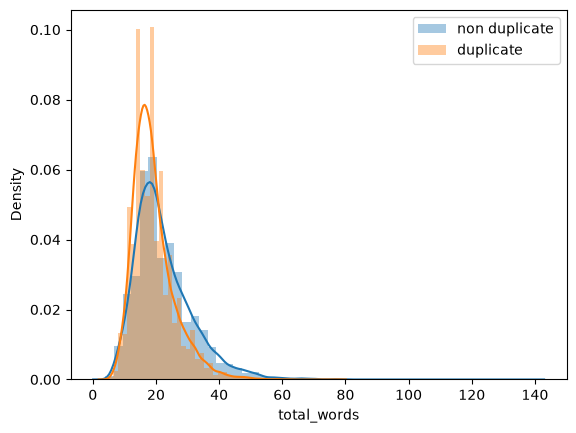

In [23]:
 # total words
sns.distplot(df[df['is_duplicate'] == 0]['total_words'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['total_words'],label='duplicate')
plt.legend()
plt.show()

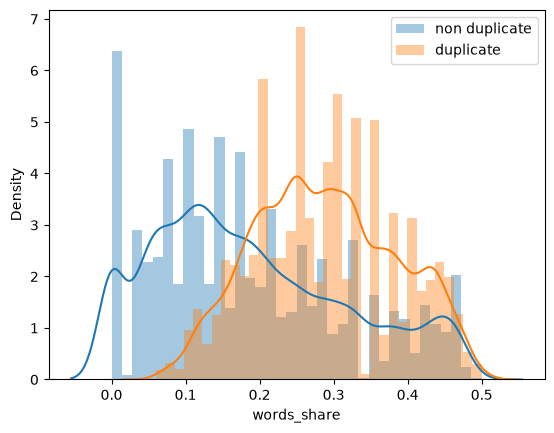

In [24]:
# word share
sns.distplot(df[df['is_duplicate'] == 0]['words_share'],label='non duplicate')
sns.distplot(df[df['is_duplicate'] == 1]['words_share'],label='duplicate')
plt.legend()
plt.show()

In [25]:
ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [28]:
df.shape
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods,total_words,words_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


In [30]:
final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods,total_words,words_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


# Applying Bag of Words 

In [31]:
from sklearn.feature_extraction.text import CountVectorizer 
cv = CountVectorizer(max_features=3000)

In [32]:
ques = list(ques_df['question1'].to_list()) + list(ques_df['question2'].to_list())
q1_arr, q2_arr = np.vsplit(cv.fit_transform(ques).toarray(),2)

In [33]:
temp_q1 = pd.DataFrame(q1_arr,index=ques_df.index) 
temp_q2 = pd.DataFrame(q2_arr,index=ques_df.index) 
temp_df  = pd.concat([temp_q1,temp_q2],axis=1)
print(temp_df.shape)
temp_df.head()

(30000, 6000)


,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
final_df = pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.head()

(30000, 6008)


,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_wrods,total_words,words_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,0,1,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(final_df.iloc[:,1:],final_df.iloc[:,0],test_size=0.2,random_state=1)

In [38]:
# Rename columns to a clean, unique range from 0 to N-1
x_train.columns = range(x_train.shape[1])
x_test.columns = range(x_test.shape[1])

In [39]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score 

rf = RandomForestClassifier() 
rf.fit(x_train,y_train) 
y_pred_rf = rf.predict(x_test)
print('Accuracy of Random Forest',accuracy_score(y_test,y_pred_rf))

Accuracy of Random Forest 0.7723333333333333


In [43]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
y_pred = xgb.predict(x_test)
print('Accuracy of Random Forest',accuracy_score(y_test,y_pred))

Accuracy of Random Forest 0.7666666666666667


# 🚀 Advanced Feature Engineering

This section outlines the advanced features extracted to capture linguistic, structural, and semantic overlaps between the question pairs.

---

## 1. Token Features
These features capture word-level overlaps by analyzing common words, stop words, and overall token counts.

*   **`cwc_min`** (Common Word Count Min): The ratio of common non-stop words to the length of the smaller question.
    $$\text{cwc\_min} = \frac{\text{Common Words}}{\min(\text{len}(Q_1), \text{len}(Q_2))}$$
*   **`cwc_max`** (Common Word Count Max): The ratio of common non-stop words to the length of the larger question.
    $$\text{cwc\_max} = \frac{\text{Common Words}}{\max(\text{len}(Q_1), \text{len}(Q_2))}$$
*   **`csc_min`** (Common Stop Words Min): The ratio of common stop words to the smaller stop word count.
*   **`csc_max`** (Common Stop Words Max): The ratio of common stop words to the larger stop word count.
*   **`ctc_min`** (Common Token Count Min): The ratio of common tokens (words + stop words) to the smaller token count.
*   **`ctc_max`** (Common Token Count Max): The ratio of common tokens (words + stop words) to the larger token count.
*   **`last_word_eq`**: Binary flag ($1$ if the last words match, $0$ otherwise).
*   **`first_word_eq`**: Binary flag ($1$ if the first words match, $0$ otherwise).

---

## 2. Length-Based Features
These features capture structural and scale differences between the two text inputs.

*   **`mean_len`**: Average length of the two questions (by word count).
*   **`abs_len_diff`**: Absolute difference in length between the two questions:
    $$|\text{len}(Q_1) - \text{len}(Q_2)|$$
*   **`longest_substr_ratio`**: Ratio of the longest common substring length to the length of the smaller question:
    $$\frac{\text{len}(\text{Longest Substring})}{\min(\text{len}(Q_1), \text{len}(Q_2))}$$

---

## 3. Fuzzy Features
Levenshtein-distance-based similarity scores from the `fuzzywuzzy` / `RapidFuzz` library to handle misspellings and word order variations.

*   **`fuzz_ratio`**: Standard edit distance ratio comparing the raw character sequences.
*   **`fuzz_partial_ratio`**: A ratio calculated by looking at the best matching substring of the longer string.
*   **`token_sort_ratio`**: Sorts the tokens alphabetically before calculating the ratio, ignoring word order.
*   **`token_set_ratio`**: Extracts unique common tokens and calculates the overlap, making it robust to duplicates and noise.

---

